<a href="https://colab.research.google.com/github/filfish2007-cav/ITStep-AI/blob/superwised_learning/DZ_Overfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Дані

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/ITStep-AI/refs/heads/superwised_learning/data/customer_spending.csv")

In [3]:
df.head()

,annual_income,account_tenure_days,age,engagement_score,support_tickets,annual_spending
0,57964.98,1170,65,35.95,5,218.46
1,27667.36,856,58,14.56,2,16.51
2,74068.69,1178,31,33.26,2,240.06
3,82232.89,741,33,87.93,2,242.77
4,16763.02,497,31,10.22,0,130.61


# Опис даних

Цу дані користувачів онлайн-сервісу **Shoply** — сайту, де люди купують товари та оформлюють підписки. Для кожного користувача зібрана інформація про його активність, дохід та взаємодію із сайтом.

* **annual_income** — скільки грошей користувач заробляє за рік
* **account_tenure_days** — скільки днів користувач зареєстрований на сайті
* **age** — вік користувача
* **engagement_score** — наскільки активно користувач користується сайтом
* **support_tickets** — скільки разів користувач звертався до служби підтримки
* **annual_spending** — скільки грошей користувач витрачає на сайті за рік


Потрібно спрогнозувати **витрати** користувача

# Завдання 1
Розділіть дані на ознаки для моделі(Х) та цільову змінну(y)

In [4]:
from sklearn.model_selection import train_test_split

y = df['annual_spending']
X = df.drop('annual_spending', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (5216, 5)
X_test shape: (1304, 5)
y_train shape: (5216,)
y_test shape: (1304,)


# Завдання 2
Розділіть дані на тренувальну та тестову вибірку

#Завдання 3
Нетренуйте дерево рішень на тренувальній вибірці

При створенні моделі використовуйте параметри за замовчуванням

In [5]:
from sklearn.tree import DecisionTreeRegressor

model_tree = DecisionTreeRegressor()
model_tree.fit(X_train, y_train)

DecisionTreeRegressor()

# Завдання 4
Спронозуйте витрати користувача для тренувальних даних та порівняйте зі справжніми

Використайте метрики MAE, MSE, R2

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pred = model_tree.predict(X_train)

mae = mean_absolute_error(y_train, pred)
mse = mean_squared_error(y_train, pred)
r2 = r2_score(y_train, pred)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R2: {r2}")

MAE: 0.0
MSE: 0.0
R2: 1.0


# Завдання 5
Спронозуйте витрати користувача для тестових даних та порівняйте зі справжніми

Використайте метрики MAE, MSE, R2

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pred = model_tree.predict(X_test)

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R2: {r2}")

MAE: 33.2695245398773
MSE: 1739.4388365030673
R2: 0.5066830799655304


# Завдання 6
Для різних значень параметра `max_depth` натренуйте модель та порахуйте метрику `MAE` на тренувальних та тестових даних

Отримайте відповідно 2 списки -- `train_mae` та `test_mae`
візуалізуйте їх

In [9]:
train_mae = []
test_mae = []

max_depths = range(1,15)

for depth in max_depths:
  tree = DecisionTreeRegressor(max_depth=depth)
  tree.fit(X_train, y_train)

  pred_train = tree.predict(X_train)
  pred_test = tree.predict(X_test)

  mae_train = mean_absolute_error(y_train, pred_train)
  mae_test = mean_absolute_error(y_test, pred_test)

  train_mae.append(mae_train)
  test_mae.append(mae_test)

test_mae

[36.28863469376778,
 32.370559942403084,
 28.151793095055726,
 26.266120493435206,
 23.86132831738924,
 23.779905538946963,
 24.00723254897602,
 24.623046378965554,
 24.89833400817051,
 26.194920538647334,
 27.307980188340608,
 28.028277811757558,
 28.918774611651283,
 29.745727485741366]

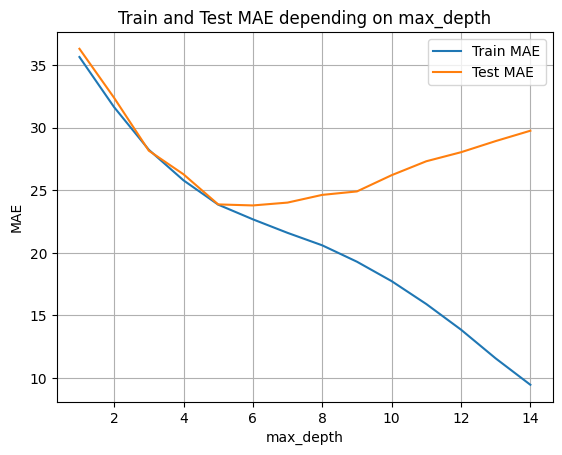

In [10]:
# код для візуалізації
# вам потрібно створити список max_depthes зі значеннями параметра який ви використовували
import matplotlib.pyplot as plt

plt.plot(max_depths, train_mae, label="Train MAE")
plt.plot(max_depths, test_mae, label="Test MAE")

plt.xlabel("max_depth")
plt.ylabel("MAE")
plt.title("Train and Test MAE depending on max_depth")
plt.legend()
plt.grid()

plt.show()

# Завдання 7
По графіку визначте оптимальне значення параметра `max_depth`

In [11]:
final_model = DecisionTreeRegressor(max_depth=5, random_state=42)
final_model.fit(X_train, y_train)
print("Фінальну модель успішно натреновано!")

Фінальну модель успішно натреновано!
